In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from libsvmdata import fetch_dataset
import time
from IPython.display import Image

In [5]:
# Setup

SEED = 42 # for reproducibility
np.random.seed(SEED)
T = 500 # number of trials

N, d = 1000, 10
X = np.random.rand(N, d )

# only use the SVD
X, _, _ = np.linalg.svd(X, full_matrices=False)

y = np.random.rand(X.shape[0])

w_star, _,  _, _ = np.linalg.lstsq(X, y, rcond=None)
err_star = np.linalg.norm(X @ w_star - y, ord=2)**2


max_removed = int(.6 * N) # only remove up to .6 of the data

In [2]:
data = pd.read_csv('./winequality-red.csv', sep=";")

In [ ]:
data = pd.read_csv('./winequality-red.csv', sep=";")

In [2]:
data = pd.read_excel('./Concrete_Data.xls')

In [6]:
X = data.drop(columns=['quality']).to_numpy(dtype=float)
y = data['quality'].to_numpy(dtype=float)

# X = data.drop(columns=['Concrete compressive strength(MPa, megapascals) ']).to_numpy(dtype=float)
# y = data['Concrete compressive strength(MPa, megapascals) '].to_numpy(dtype=float)

N, d = X.shape

X, _, _ = np.linalg.svd(X, full_matrices=False)

w_star, _,  _, _ = np.linalg.lstsq(X, y, rcond=None)
err_star = np.linalg.norm(X @ w_star - y, ord=2)**2

max_removed = int(.6 * N)

In [7]:
# chaining
# use at least d points, label budget <b> -> index <b> - d

chaining_exps = [np.full(N, np.nan) for _ in range(T)] # will not use all of this
for t in range(T):
    start_time = time.time()
    AtA = np.zeros((d, d), dtype=float)
    X_minus = X.copy()
    y_minus = y.copy()
    for k in range(1, max_removed+1):
        # the inverse is negligible since matrix is of size d x d
        leverages = np.einsum('ij,jk,ik->i', X_minus, np.linalg.inv(np.eye(d) -  AtA), X_minus)
        leverages[leverages == 0] = 1 # this will ingnore 0 rows, will not sample rows that is already picked and has been zeroed out
        probs = (1 - leverages)**2 / leverages
        probs /= np.sum(probs)
        
        i = np.random.choice(np.arange(N), p=probs)
        X_minus[i] = 0
        wA_minus = np.linalg.lstsq(X_minus, y_minus, rcond=None)[0]
        label_budget = N - k - 1
        chaining_exps[t][label_budget] = np.linalg.norm(X @ wA_minus - y, ord=2)**2 / err_star
    end_time = time.time()
    print(f"Trial {t+1}/{T} completed in {end_time - start_time:.2f} seconds")

chaining_exps = np.array(chaining_exps)

Trial 1/500 completed in 0.57 seconds
Trial 2/500 completed in 0.59 seconds
Trial 3/500 completed in 0.62 seconds
Trial 4/500 completed in 0.62 seconds
Trial 5/500 completed in 0.59 seconds
Trial 6/500 completed in 0.58 seconds
Trial 7/500 completed in 0.58 seconds
Trial 8/500 completed in 0.55 seconds
Trial 9/500 completed in 0.54 seconds
Trial 10/500 completed in 0.53 seconds
Trial 11/500 completed in 0.59 seconds
Trial 12/500 completed in 0.73 seconds
Trial 13/500 completed in 0.77 seconds
Trial 14/500 completed in 0.73 seconds
Trial 15/500 completed in 0.71 seconds
Trial 16/500 completed in 0.72 seconds
Trial 17/500 completed in 0.69 seconds
Trial 18/500 completed in 0.72 seconds
Trial 19/500 completed in 0.79 seconds
Trial 20/500 completed in 0.76 seconds
Trial 21/500 completed in 0.74 seconds
Trial 22/500 completed in 0.75 seconds
Trial 23/500 completed in 0.66 seconds
Trial 24/500 completed in 0.67 seconds
Trial 25/500 completed in 0.66 seconds
Trial 26/500 completed in 0.64 sec

In [ ]:
budgets = np.arange(N - max_removed, N)


chaining_data = []
poly_sampling_data = []
leverage_score_data = []
for t in range(T-1):
    for b in budgets:
        # print(t, b-1)
        chaining_data.append({
            "Budget": b,
            "Error": chaining_exps[t][b-1]-1,
            "Trial": t
        })

chaining_df = pd.DataFrame(chaining_data)

# Plot
sns.set(style="whitegrid", context="talk")
plt.figure()
sns.lineplot(
    data=chaining_df,
    x="Budget",
    y="Error",
    errorbar="sd",   # shaded ±1 std
    estimator="mean",
    label="(A)"
)



plt.axhline(y=d/N, linestyle='--', label="d/N")

plt.xlim(N - max_removed, N)
plt.yscale("log")

plt.xlabel("Label Budget")
plt.ylabel("Approximation Error - 1")
plt.legend()
plt.tight_layout()
plt.show()

### Red Wine Dataset

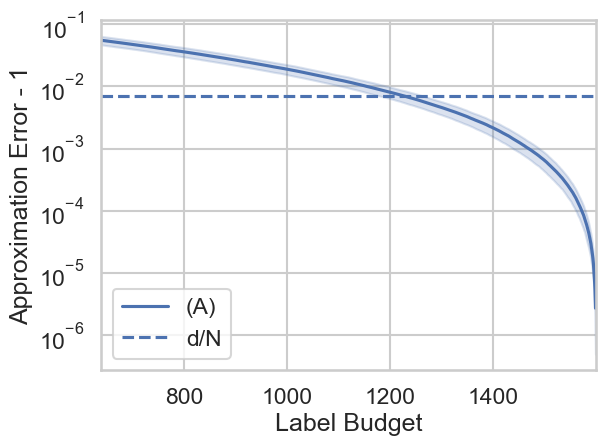

In [3]:
Image(filename='WineQualityRed_Fixed.png')

### White Wine Dataset

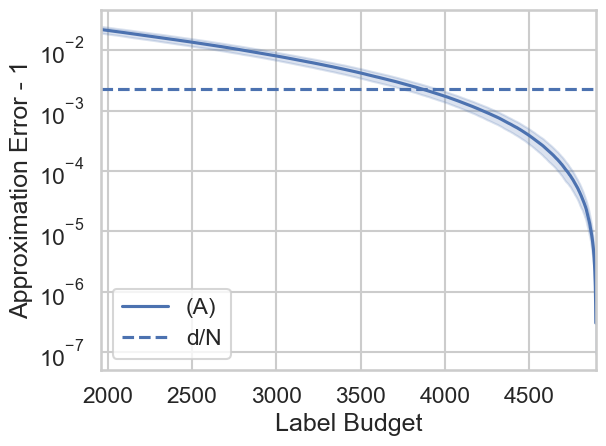

In [4]:
Image(filename='WineQualityWhite_Fixed.png')

### Concrete Compressive Strength Dataset

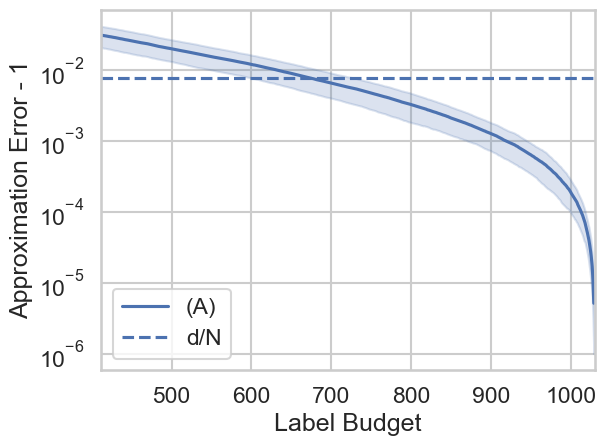

In [5]:
Image(filename='Concrete_Fixed.png')